# 1. Word Norms

Load psycholinguistic concreteness/imageability ratings from published sources,
examine how words are classified as abstract or concrete, and visualize the results.

In [1]:
from abstraction.norms import (
    get_orignorms, get_allnorms, get_origfields,
    format_norms_as_long, classify_word, get_origcontrasts,
    corr_norms,
)
from abstraction.plotting import plot_norms, plot_allnorms
import pandas as pd
pd.options.display.max_colwidth = 80

## Load empirical norms

These come from four published psycholinguistic studies:
- Paivio (1968) — concreteness and imagery
- MRC (1987) — concreteness and imagery
- Brysbaert (2014) — concreteness
- Lancaster Sensorimotor Norms (2017) — visual and haptic

In [2]:
orignorms = get_orignorms()
print(f'{len(orignorms)} words, {len(orignorms.columns)} norm sources')
orignorms.head(10)

36471 words, 8 norm sources


,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag,Abs-Conc.Median
word,,,,,,,,
I,NaN,NaN,NaN,NaN,0.950954,NaN,NaN,0.950954
Inf,NaN,NaN,NaN,NaN,-1.584783,NaN,NaN,-1.584783
a.lgebra,NaN,NaN,NaN,NaN,NaN,-0.050006,0.151973,0.050983
aardvark,0.630471,1.413671,NaN,NaN,1.690955,NaN,NaN,1.413671
aback,-0.822187,-0.043892,NaN,NaN,-1.298649,NaN,NaN,-0.822187
abacus,2.919588,1.211460,NaN,NaN,1.533088,NaN,NaN,1.533088
abandon,-0.822187,-0.768556,NaN,-0.493132,-0.420514,NaN,NaN,-0.630844
abandoned,-1.082577,-0.095131,NaN,NaN,-0.440248,NaN,NaN,-0.440248
abandonee,0.357596,1.203683,NaN,NaN,-0.045581,NaN,NaN,0.357596


## Inspect specific words

In [3]:
sample_words = ['rock', 'virtue', 'justice', 'face', 'anxiety', 'pleasure', 'elbow', 'belief']
orignorms.loc[[w for w in sample_words if w in orignorms.index]].sort_values("Abs-Conc.Median")

,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag,Abs-Conc.Median
word,,,,,,,,
belief,-1.049659,-1.990132,-1.389403,-1.104661,-1.752516,-1.808242,-1.601589,-1.601589
virtue,-0.693775,-1.361462,-1.611551,-0.894733,-1.328249,-1.856194,-1.170385,-1.328249
justice,-0.870341,0.153744,-1.084978,-0.639169,-1.495983,-1.472579,-0.976343,-0.976343
anxiety,-0.626190,-1.084079,-1.628006,-0.246695,-0.746115,-1.765618,-0.667314,-0.746115
pleasure,1.912983,-0.070243,-1.126116,0.565634,-0.913848,-1.515202,-0.113936,-0.113936
elbow,3.066854,1.073690,1.383334,1.396218,2.006689,1.063543,0.964073,1.383334
rock,2.731608,1.385672,1.325740,1.487491,1.917889,1.074198,1.014380,1.385672
face,2.240433,2.337617,1.317512,1.204545,1.878422,NaN,NaN,1.878422


## Classify words into fields

Words with z >= 1.0 are classified as **Concrete**, z <= -1.0 as **Abstract**, otherwise **Neither**.

In [4]:
median = orignorms['Abs-Conc.Median']
classified = median.apply(classify_word)
classified.value_counts()

Abs-Conc.Median
Neither     27255
Concrete     5423
Abstract     3793
Name: count, dtype: int64

In [5]:
# Most abstract words (by median across sources)
median.sort_values().head(20)

word
naiad         -2.291210
equanimity    -2.201997
zdoes         -2.181682
hyssop        -2.163427
convocation   -2.104164
abstruse      -2.044772
mohur         -2.039307
gadid         -2.022665
yso           -2.016499
menad         -2.010576
philology     -1.996370
gybe          -1.992003
monad         -1.989689
lagan         -1.975548
nabob         -1.956975
indolence     -1.950678
aweigh        -1.932292
sagacity      -1.927859
metis         -1.926247
avowal        -1.918085
Name: Abs-Conc.Median, dtype: float64

In [6]:
# Most concrete words
median.sort_values(ascending=False).head(20)

word
snowy            2.269177
baseball         2.261857
cleavage         2.206958
swimmingpool     2.183626
naked            2.183626
longhair         2.131283
hairless         2.130100
t-shirt          2.094964
flyswatter       2.076708
stylus           2.073632
rainy            2.064221
undershorts      2.064221
rollingpin       2.064221
pockmark         2.049018
eyeglasses       2.039950
computer         2.020302
particleboard    2.020302
sunglasses       2.010005
lollypop         2.006689
boots            2.006689
Name: Abs-Conc.Median, dtype: float64

## Correlations between norm sources

In [7]:
corr_norms(orignorms)

,index,variable,value,value_p
8,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,0.446060,0.000000e+00
24,Abs-Conc.LSN-Hapt,Abs-Conc.MRC-Imag,0.508007,1.243604e-248
17,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,0.526622,1.461438e-240
32,Abs-Conc.LSN-Hapt,Abs-Conc.MT-Conc,0.534039,0.000000e+00
48,Abs-Conc.LSN-Hapt,Abs-Conc.PAV-Imag,0.546960,2.519648e-66
33,Abs-Conc.LSN-Imag,Abs-Conc.MT-Conc,0.550552,0.000000e+00
25,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Imag,0.552383,9.760984e-303
16,Abs-Conc.LSN-Hapt,Abs-Conc.MRC-Conc,0.558668,9.121047e-277
40,Abs-Conc.LSN-Hapt,Abs-Conc.PAV-Conc,0.566687,2.860402e-72
41,Abs-Conc.LSN-Imag,Abs-Conc.PAV-Conc,0.579153,3.901882e-76


## Load all norms (empirical + historical vector-based)

In [8]:
allnorms = get_allnorms()
print(f'{len(allnorms)} words, {len(allnorms.columns)} columns')
allnorms.head()

146090 words, 56 columns


,Abs-Conc.LSN-Hapt.C16,Abs-Conc.LSN-Imag.C16,Abs-Conc.MRC-Conc.C16,Abs-Conc.MRC-Imag.C16,Abs-Conc.MT-Conc.C16,Abs-Conc.Median.C16,Abs-Conc.PAV-Conc.C16,Abs-Conc.PAV-Imag.C16,Abs-Conc.LSN-Hapt.C17,Abs-Conc.LSN-Imag.C17,...,Abs-Conc.PAV-Conc.median,Abs-Conc.PAV-Imag.median,Abs-Conc.LSN-Hapt.orig,Abs-Conc.LSN-Imag.orig,Abs-Conc.MRC-Conc.orig,Abs-Conc.MRC-Imag.orig,Abs-Conc.MT-Conc.orig,Abs-Conc.PAV-Conc.orig,Abs-Conc.PAV-Imag.orig,Abs-Conc.Median.orig
word,,,,,,,,,,,,,,,,,,,,,
I,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.950954,NaN,NaN,0.950954
Inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.584783,NaN,NaN,-1.584783
a'ch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.538195,0.574928,...,0.675046,0.707585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a'mighty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.460244,0.642819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a'most,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.188050,1.127782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot word positions across all sources

Each word appears as a label, positioned by its z-score, across empirical and historical norm sources.

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'color' aesthetic. Make sure you have mapped a variable to it
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'shape' aesthetic. Make sure you have mapped a variable to it


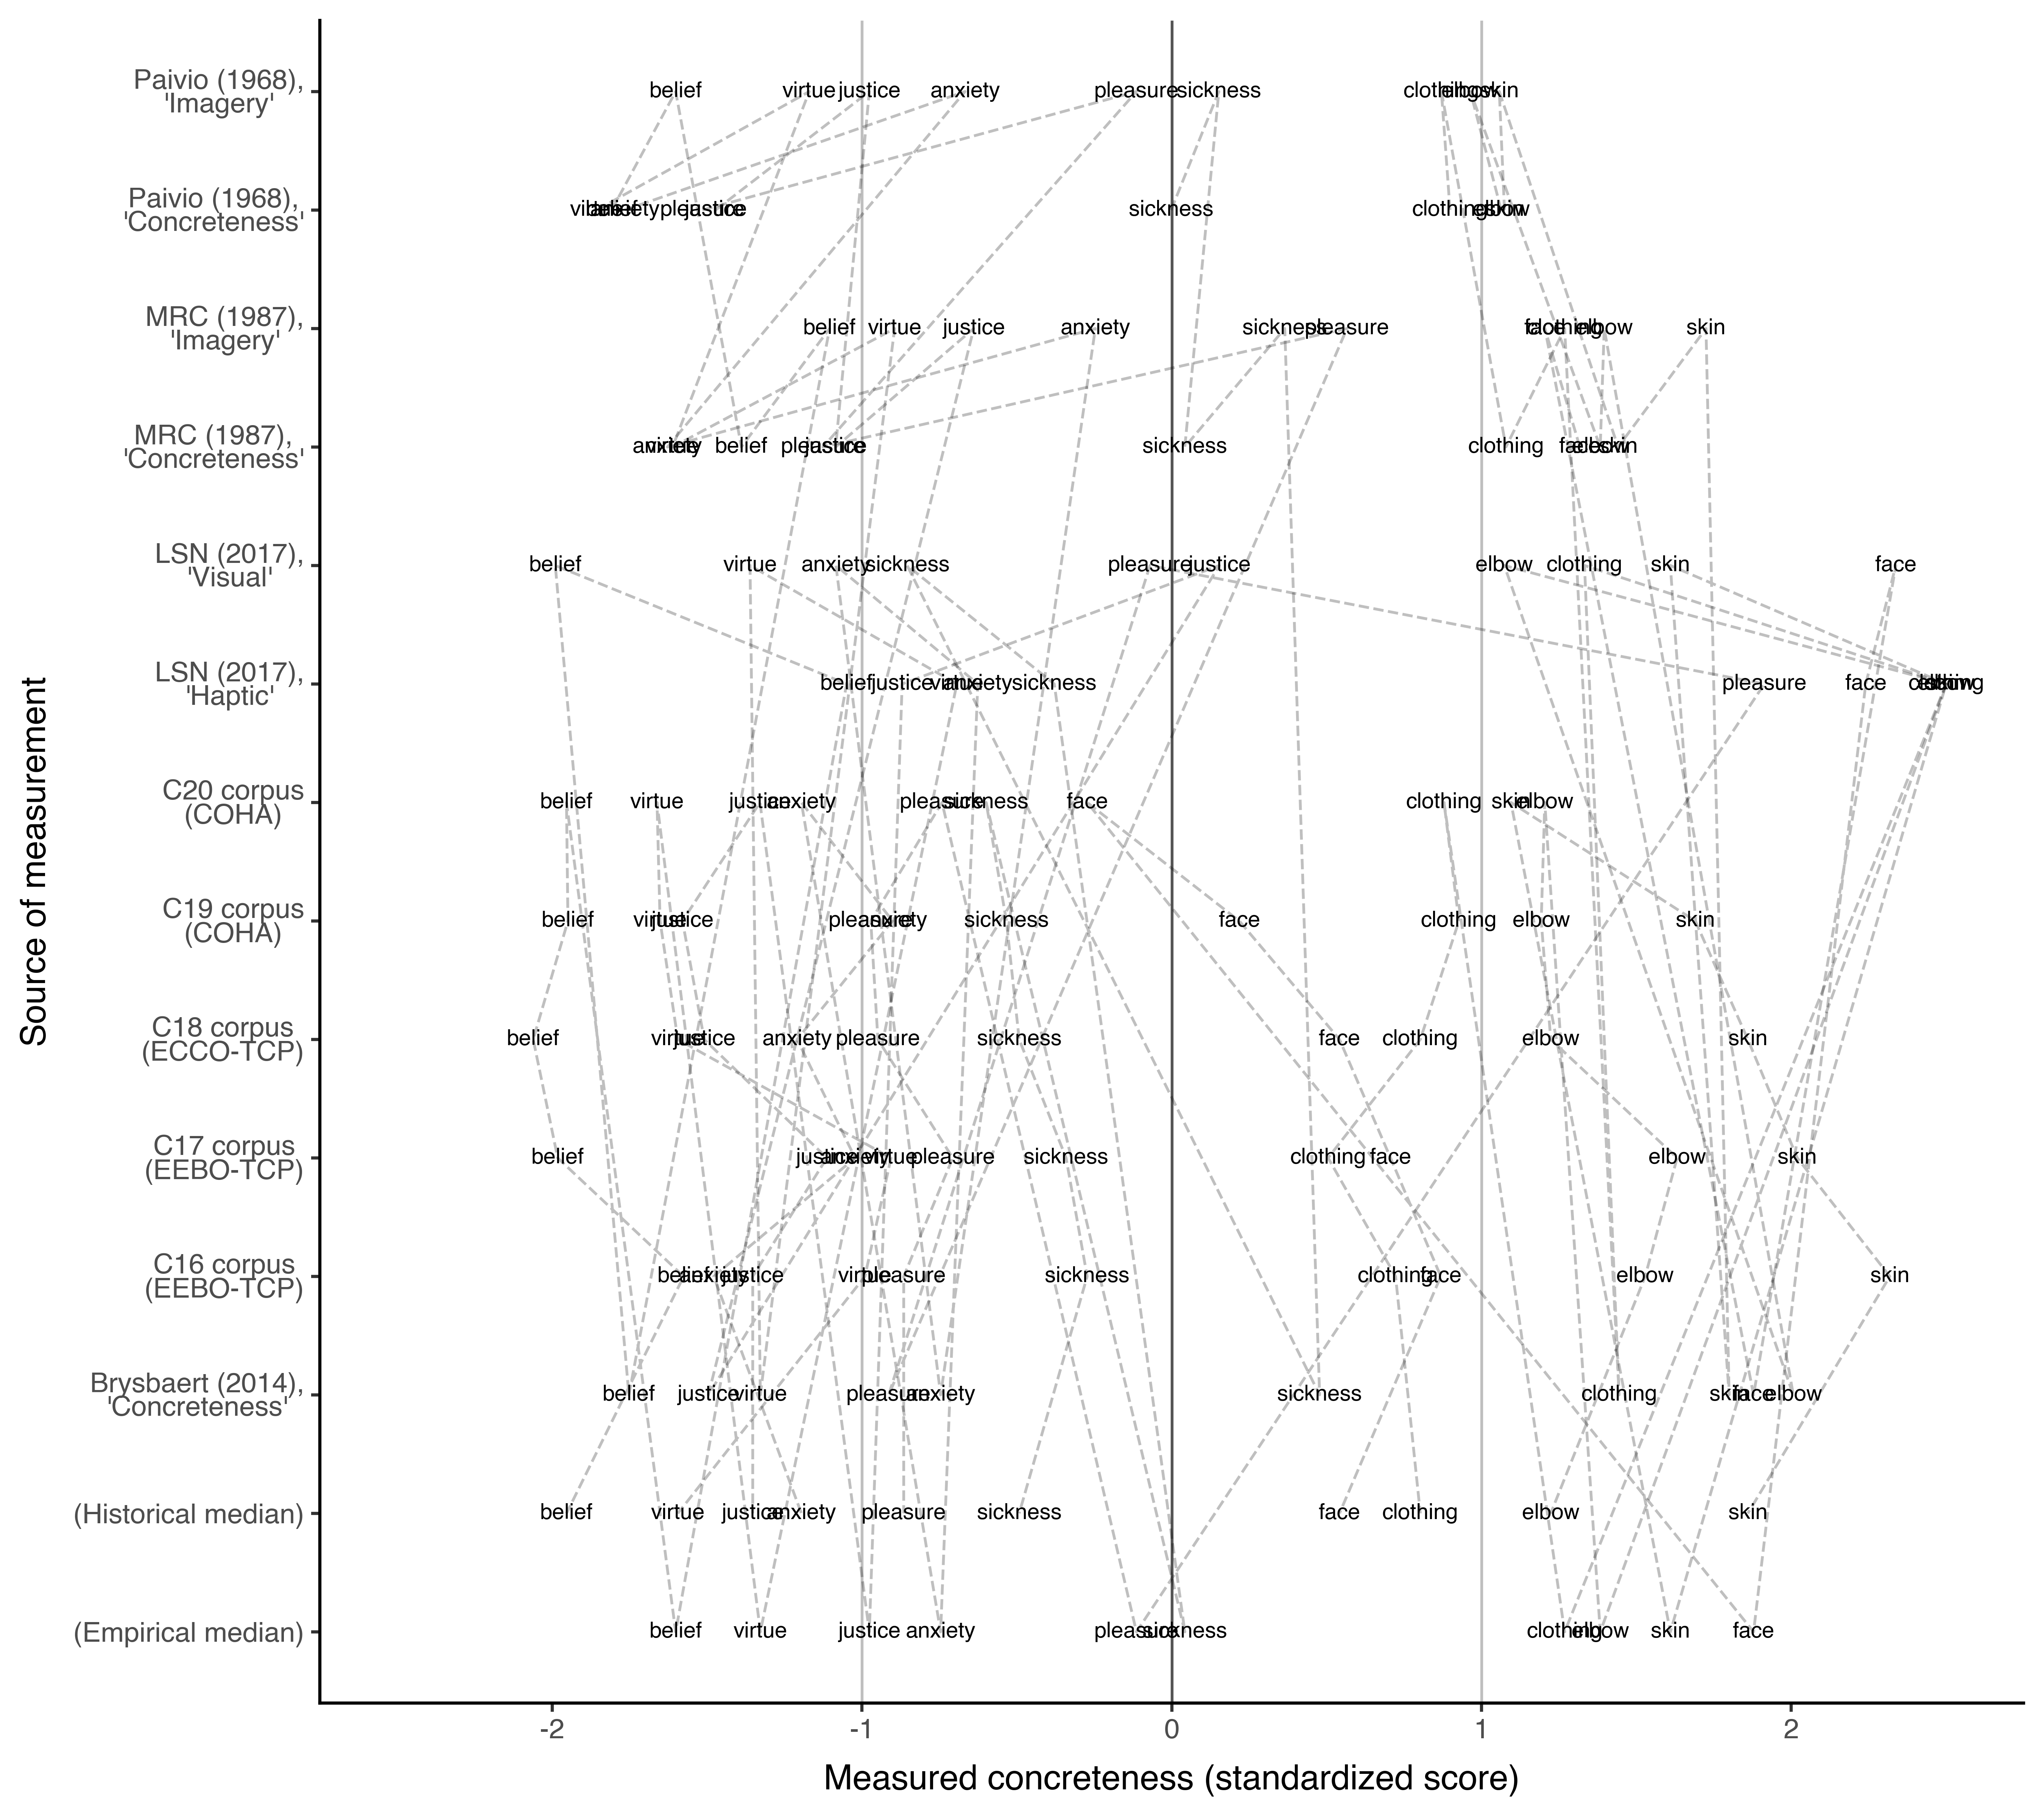

In [9]:
WORDS = {'belief', 'sickness', 'clothing', 'elbow', 'virtue',
         'anxiety', 'pleasure', 'justice', 'skin', 'face', 'interest'}

dfnorms = format_norms_as_long(allnorms)
plot_allnorms(dfnorms, words=WORDS, jitter=False)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


21 [-0.57012668 -0.17106616]
30 [0.08670988 0.75971682]
74 [0.67981518 0.13343347]


/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'fill' aesthetic. Make sure you have mapped a variable to it
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'color' aesthetic. Make sure you have mapped a variable to it
/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'shape' aesthetic. Make sure you have mapped a variable to it


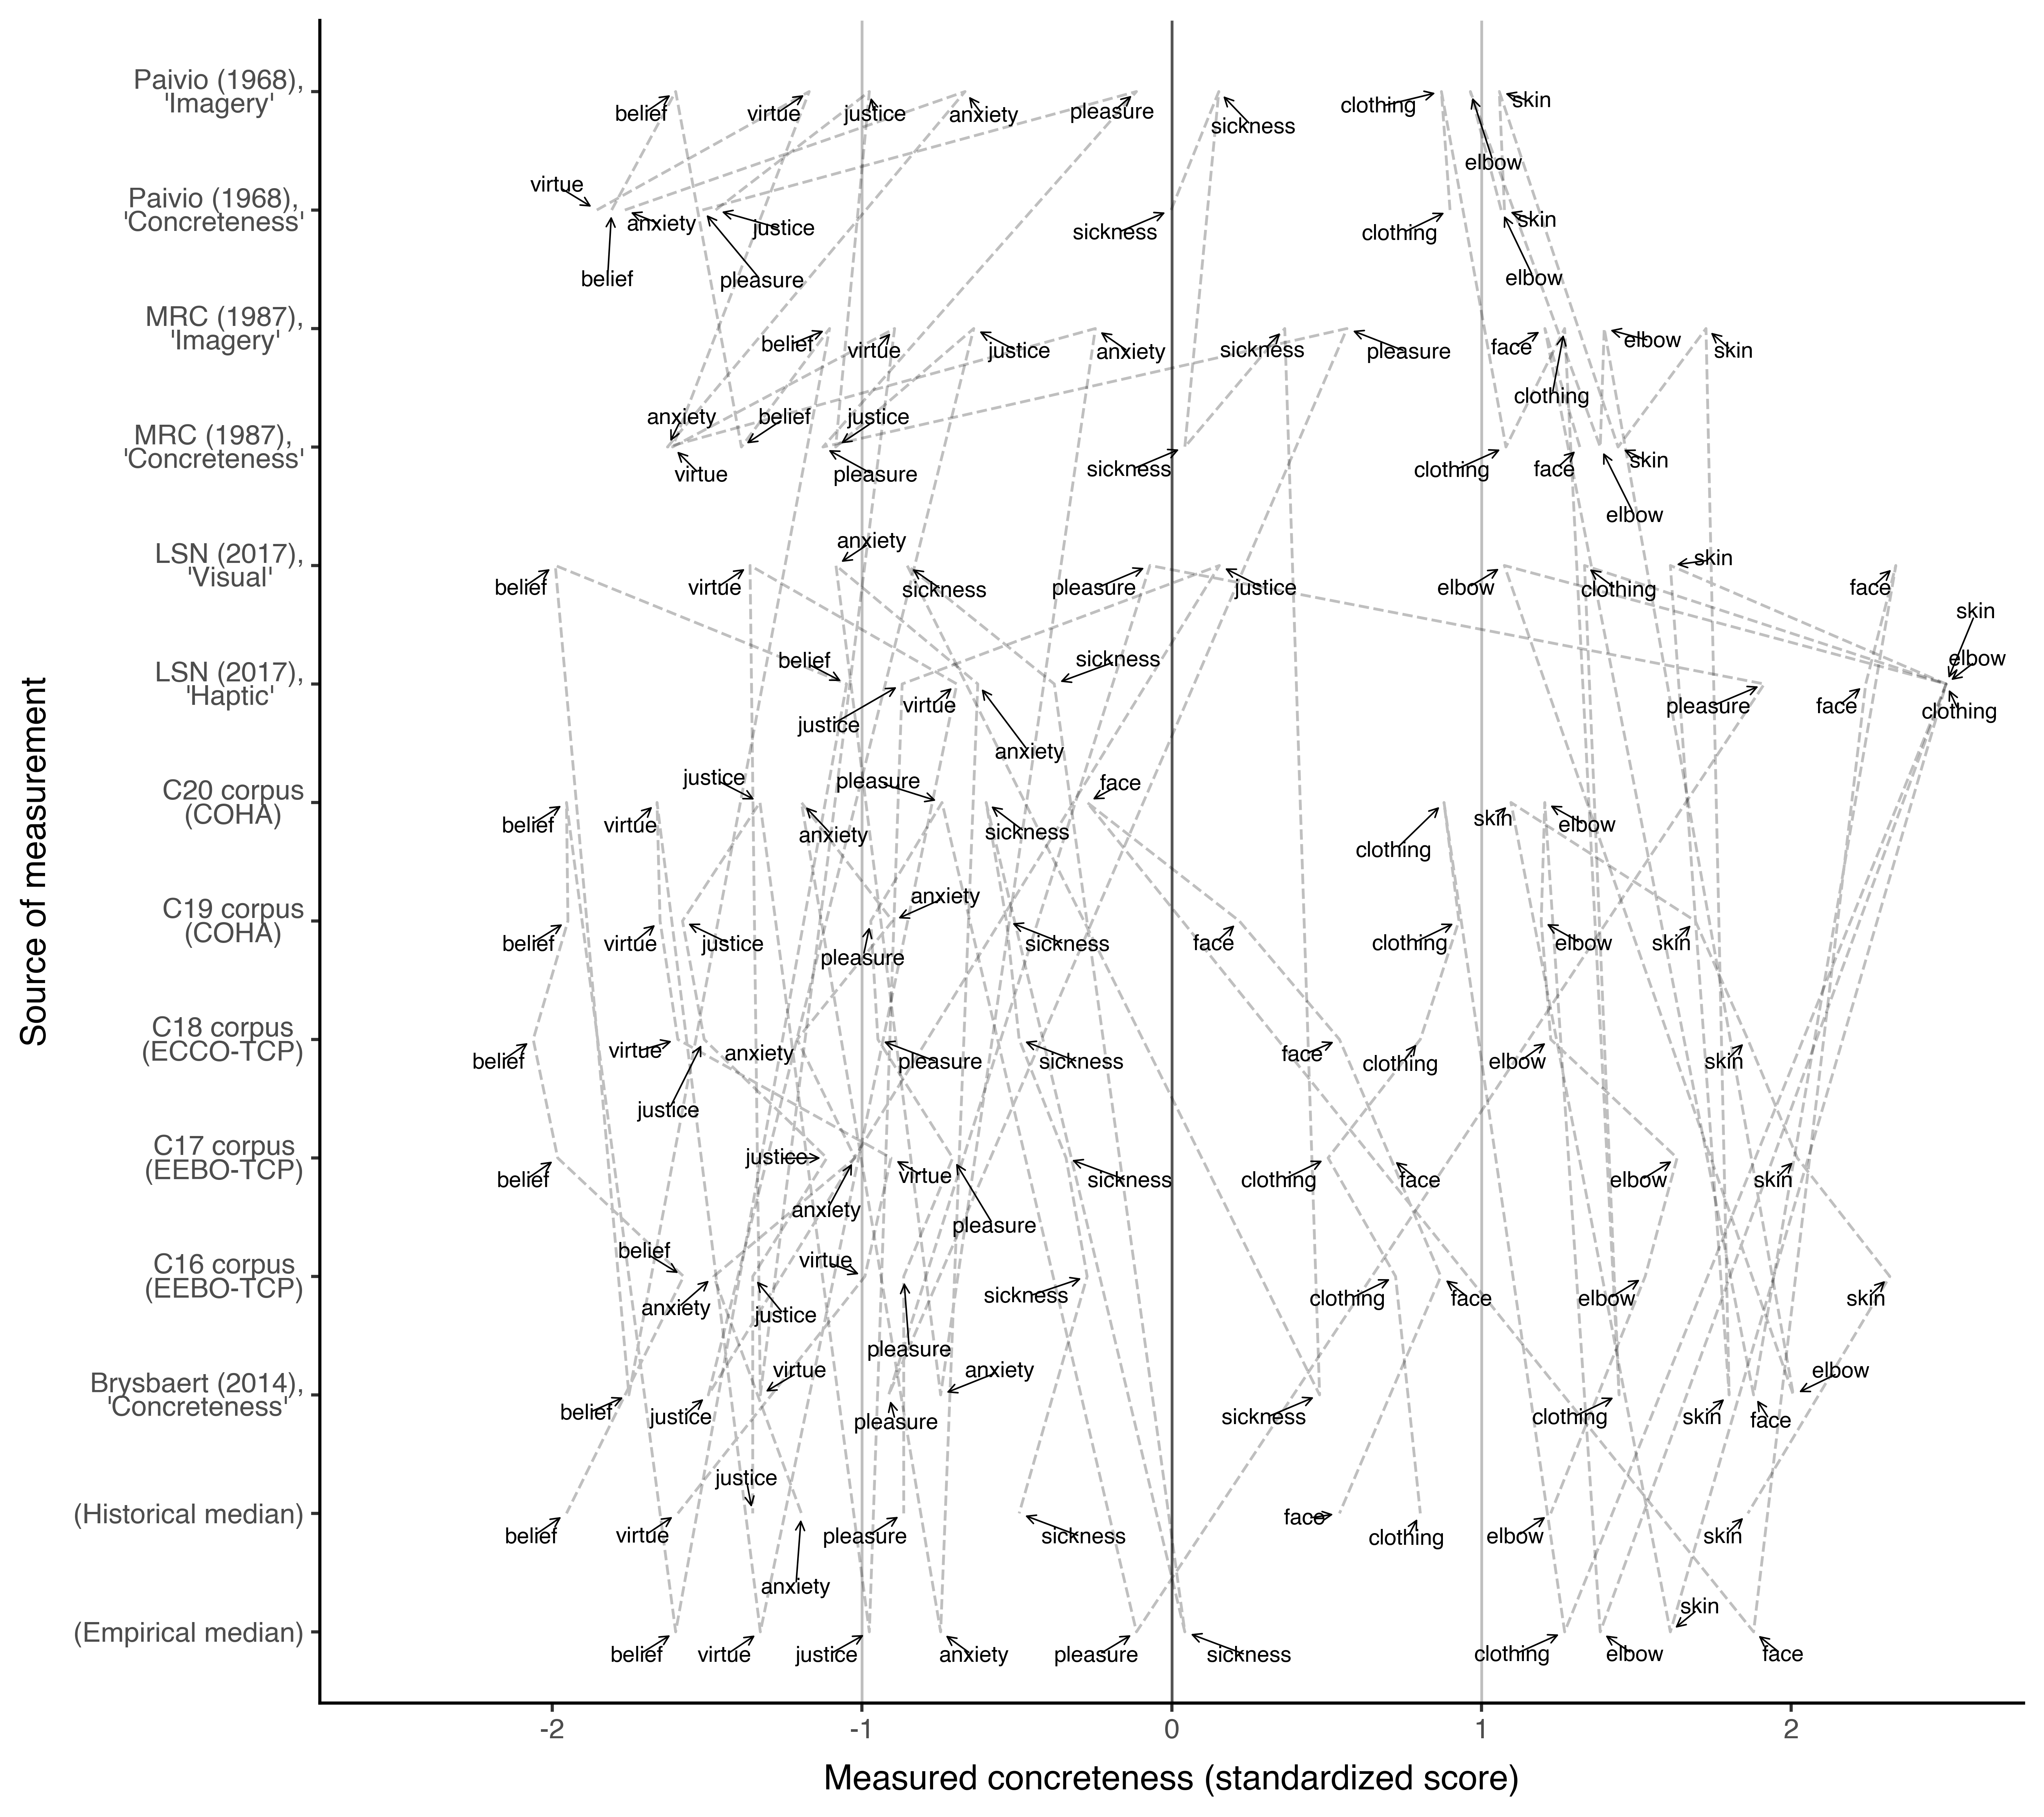

In [12]:
# With jitter to reduce overlap
plot_allnorms(dfnorms, words=WORDS, jitter=True)